In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
# =========================
# Helpers
# =========================

def gaussian_pdf(pos, mu, cov):
    n = mu.shape[0]
    cov_det = np.linalg.det(cov)
    cov_inv = np.linalg.inv(cov)
    N = np.sqrt((2*np.pi)**n * cov_det)
    diff = pos - mu
    return np.exp(-0.5 * np.einsum('...i,ij,...j->...', diff, cov_inv, diff)) / N

def normalize_2d(z, x, y):
    Z = np.trapz(np.trapz(z, x, axis=1), y, axis=0)
    return z / (Z + 1e-15)

def moment_match_from_density(pos, z):
    Z = z.sum()
    weights = z.reshape(-1) / Z
    pts = pos.reshape(-1, 2)
    mu = (weights[:,None]*pts).sum(axis=0)
    diff = pts - mu
    cov = (weights[:,None,None] * np.einsum("ni,nj->nij", diff, diff)).sum(axis=0)
    return mu, cov

# ==========PoE===============
def poe_moment_gauss_M(mus, covs):
    precs = [np.linalg.inv(S) for S in covs]
    prec_sum = sum(precs)
    cov = np.linalg.inv(prec_sum)
    mu = cov @ sum(P @ m for P,m in zip(precs, mus))
    return mu, cov

def poe_density(experts):
    return np.prod(experts, axis=0)

# ==========MoE===============
def moe_density(experts):
    return sum(experts)/len(experts)

# ==========Hellinger===============
def bhattacharyya_diag(mu1, std1, mu2, std2):
    S = 1.0
    for d in range(len(mu1)):
        s1, s2 = std1[d], std2[d]
        den = s1**2 + s2**2
        pre = np.sqrt(2*s1*s2/den)
        expo = np.exp(-(mu1[d]-mu2[d])**2/(4*den))
        S *= pre * expo
    return S

def cross_params_diag(mu1, std1, mu2, std2):
    mean = np.zeros_like(mu1, dtype=float)
    var  = np.zeros_like(mu1, dtype=float)
    for d in range(len(mu1)):
        v1, v2 = std1[d]**2, std2[d]**2
        mean[d] = (mu1[d]*v1 + mu2[d]*v2) / (v1 + v2)
        var[d]  = 2*v1*v2 / (v1 + v2)
    return mean, np.diag(var)

def holder_alpha_half_moment_gauss_M(mus, covs, diag_mode=None):
    M = len(mus)
    d = mus[0].shape[0]
    w = 1.0 / M
    stds = [np.sqrt(np.diag(c)) for c in covs]
    # Normalization constant
    Z = M * (w**2)  # sum of wi^2 terms
    for i in range(M):
        for j in range(i+1, M):
            S_ij = bhattacharyya_diag(mus[i], stds[i], mus[j], stds[j])
            Z += 2 * (w * w) * S_ij
    # First moment (mean)
    mu = np.zeros(d)
    for i in range(M):
        mu += (w**2) * mus[i]
    for i in range(M):
        for j in range(i+1, M):
            S_ij = bhattacharyya_diag(mus[i], stds[i], mus[j], stds[j])
            mu_ij, _ = cross_params_diag(mus[i], stds[i], mus[j], stds[j])
            mu += 2 * (w * w) * S_ij * mu_ij
    mu /= Z
    # Second moment
    Exx = np.zeros((d, d))
    for i in range(M):
        Exx += (w**2) * (covs[i] + np.outer(mus[i], mus[i]))
    for i in range(M):
        for j in range(i+1, M):
            S_ij = bhattacharyya_diag(mus[i], stds[i], mus[j], stds[j])
            mu_ij, cov_ij = cross_params_diag(mus[i], stds[i], mus[j], stds[j])
            Exx += 2 * (w * w) * S_ij * (cov_ij + np.outer(mu_ij, mu_ij))
    cov = Exx / Z - np.outer(mu, mu)
    cov = 0.5 * (cov + cov.T)

    if diag_mode == "fwd":
        cov = np.diag(np.diag(cov))

    return mu, cov

def holder_alpha_density(experts, alpha=0.5):
    return (sum(np.sqrt(z) for z in experts)/len(experts))**2

# ==========WB===============
def wasserstein_barycenter_gauss_M(mus, covs):
    M = len(mus)
    mu = np.mean(mus, axis=0)
    stds = [np.sqrt(np.diag(c)) for c in covs]
    std = np.mean(stds, axis=0)
    cov = np.diag(std**2)
    return mu, cov

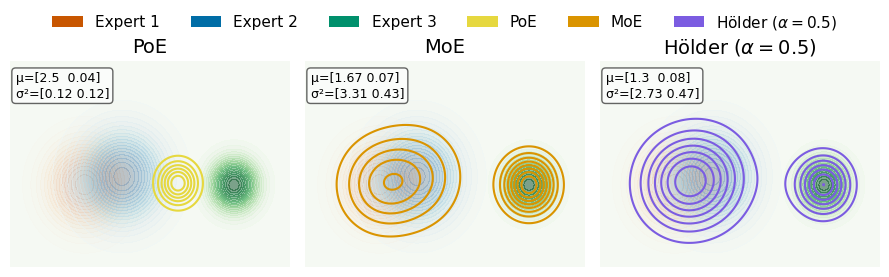

In [3]:
# =========================
# Problem setup
# =========================
# Two experts agree (close)
mu1 = np.array([0.0, 0.0]); cov1 = np.diag([0.5, 0.5])
mu2 = np.array([1.0, 0.2]); cov2 = np.diag([0.6, 0.6])

# One expert disagrees (far, sharp)
mu3 = np.array([4.0, 0.0]); cov3 = np.diag([0.2, 0.2])

x = np.linspace(-2, 5.5, 250)
y = np.linspace(-2, 3, 250)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

z1 = gaussian_pdf(pos, mu1, cov1)
z2 = gaussian_pdf(pos, mu2, cov2)
z3 = gaussian_pdf(pos, mu3, cov3)

# =========================
# Aggregators
# =========================
z_moe = normalize_2d(moe_density([z1, z2, z3]), x, y)
mu_moe, cov_moe = moment_match_from_density(pos, z_moe)

z_poe = normalize_2d(poe_density([z1, z2, z3]), x, y)
mu_poe, cov_poe = moment_match_from_density(pos, z_poe)

z_holder = normalize_2d(holder_alpha_density([z1, z2, z3], alpha=0.5), x, y)
mu_holder, cov_holder = moment_match_from_density(pos, z_holder)

# =========================
# Plot
# =========================
fig, axes = plt.subplots(1, 3, figsize=(9, 2.8))

panels = [
    ("PoE", z_poe, "#E6D83F", mu_poe, cov_poe),
    ("MoE", z_moe, "#DA9400", mu_moe, cov_moe),
    (r"Hölder ($\alpha=0.5$)", z_holder, "#7B5CE1", mu_holder, cov_holder),
]

from matplotlib.colors import LinearSegmentedColormap

def solid_cmap(hex_color):
    return LinearSegmentedColormap.from_list("", ["white", hex_color])

for ax, (title, zc, color, mu, cov) in zip(axes, panels):
    # plot experts
    ax.contourf(X, Y, z1, levels=20, alpha=0.50, cmap="Oranges")
    ax.contour(X, Y, z1, levels=8, linewidths=0.00001, alpha=0.25, colors="#C85600")
    ax.contourf(X, Y, z2, levels=20, alpha=0.50, cmap="Blues")
    ax.contour(X, Y, z2, levels=8, linewidths=0.00001, alpha=0.25, colors="#006DA6")
    ax.contourf(X, Y, z3, levels=20, alpha=0.50, cmap="Greens")
    ax.contour(X, Y, z3, levels=8, linewidths=0.00001, alpha=0.25, colors="#00906C")
    # aggregator contour
    ax.contour(X, Y, zc, levels=8, colors=color)
    # title
    ax.set_title(title, fontsize=14)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    # annotate
    var_diag = np.round(np.diag(cov), 2)
    ax.text(0.02, 0.95, f"μ={np.round(mu,2)}\nσ²={var_diag}",
            transform=ax.transAxes, fontsize=9, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.6))

legend_elements = [
    Patch(facecolor="#C85600", label="Expert 1"),   # brighter orange
    Patch(facecolor="#006DA6", label="Expert 2"),   # brighter blue
    Patch(facecolor="#00906C", label="Expert 3"),   # brighter green
    Patch(facecolor="#E6D83F", label="PoE"),        # unchanged
    Patch(facecolor="#DA9400", label="MoE"),        # unchanged
    Patch(facecolor="#7B5CE1", label=r"Hölder ($\alpha=0.5$)"), # unchanged
]

fig.legend(handles=legend_elements, loc="upper center", ncol=7, frameon=False, fontsize=11)

plt.tight_layout(rect=[0,0,1,0.93])
plt.show()
fig.savefig("plots/distributions_experts.pdf", format="pdf", bbox_inches="tight")

In [4]:
import numpy as np
from scipy.stats import multivariate_normal

# --- Oracle ---
mu_oracle = np.array([0.,0.])
cov_oracle = np.eye(2)

from numpy.linalg import inv
from scipy.stats import chi2

# --- Metrics ---
def expected_nll_gauss(mu, Sigma, M=10_000, seed=0):
    rng = np.random.default_rng(seed)
    d = len(mu)
    z = rng.normal(0, 1, size=(M, d))  # oracle samples

    diff = z - mu
    Sinv = np.linalg.inv(Sigma)
    log_det = np.log(np.linalg.det(Sigma) + 1e-12)
    logq = -0.5 * (d*np.log(2*np.pi) + log_det + np.sum(diff @ Sinv * diff, axis=1))

    return -float(np.mean(logq))  # expected NLL

def bhattacharyya(mu1, cov1, mu2, cov2):
    cov_mean = 0.5*(cov1+cov2)
    diff = mu1 - mu2
    term1 = 0.125 * diff.T @ np.linalg.inv(cov_mean) @ diff
    term2 = 0.5*np.log(np.linalg.det(cov_mean)/(np.sqrt(np.linalg.det(cov1)*np.linalg.det(cov2))+1e-12)+1e-12)
    return np.exp(-(term1+term2))

def sharpness(cov):
    return np.trace(cov)

def expected_nll_samples(samples):
    mu = np.mean(samples, axis=0)
    cov = np.cov(samples.T)
    return expected_nll_gauss(mu, cov)

def bc_samples(x_oracle, samples):
    mu = np.mean(samples, axis=0)
    cov = np.cov(samples.T)
    return bhattacharyya(mu_oracle, cov_oracle, mu, cov)

def sharp_samples(samples):
    cov = np.cov(samples.T)
    return sharpness(cov)

# --- Make experts ---
def make_experts(n_good, n_bad, seed=0):
    rng = np.random.default_rng(seed)
    mus, covs = [], []
    for _ in range(n_good):
        mus.append(rng.normal(0,0.5,2))
        covs.append(np.eye(2)*0.5)
    for _ in range(n_bad):
        mus.append(rng.normal(4,0.2,2))
        covs.append(np.eye(2)*0.2)
    return mus, covs

# --- Sampling from aggregators ---
def sample_moe(mus, covs, n_samples=5000):
    K = len(mus)
    idx = np.random.choice(K, size=n_samples, replace=True)  # uniform mixture
    samples = np.array([
        np.random.multivariate_normal(mus[i], covs[i])
        for i in idx
    ])
    return samples

def build_holder_half(mus, covs, weights=None):
    K = len(mus)
    if weights is None:
        weights = np.ones(K) / K

    comps = []
    unnorm_w = []
    for i in range(K):
        for j in range(K):
            Si, Sj = covs[i], covs[j]
            mui, muj = mus[i], mus[j]

            Si_inv = np.linalg.inv(Si)
            Sj_inv = np.linalg.inv(Sj)
            prec = 0.5 * (Si_inv + Sj_inv)
            Sij = np.linalg.inv(prec)
            muij = Sij @ (0.5 * (Si_inv @ mui + Sj_inv @ muj))

            # BC between Gaussian i and j
            Sbar = 0.5 * (Si + Sj)
            diff = muj - mui
            term1 = 0.125 * diff.T @ np.linalg.inv(Sbar) @ diff
            term2 = 0.5 * np.log(np.linalg.det(Sbar) / np.sqrt(np.linalg.det(Si) * np.linalg.det(Sj)))
            DB = term1 + term2
            BCij = np.exp(-DB)

            comps.append(multivariate_normal(mean=muij, cov=Sij))
            unnorm_w.append(weights[i]*weights[j]*BCij)

    pis = np.array(unnorm_w) / np.sum(unnorm_w)
    return comps, pis

def sample_holder_half(mus, covs, n_samples=5000):
    comps, pis = build_holder_half(mus, covs)
    idx = np.random.choice(len(comps), size=n_samples, p=pis)
    samples = np.array([comps[k].rvs() for k in idx])
    return samples

In [5]:
def run_metrics_good(max_M=6, n_bad=3, n_samples=5000):
    x = np.linspace(-5,6,150); y = np.linspace(-5,6,150)
    X,Y = np.meshgrid(x,y); pos=np.dstack((X,Y))

    results = {m:{"NLL":[],"BC":[],"Sharp":[]}
               for m in ["PoE","MoE","Hellinger",r"Hölder ($\alpha=0.5$)", "WB"]}

    for M_good in range(2, max_M+1):
        mus, covs = make_experts(M_good, n_bad, seed=42)

        # --- PoE (closed form Gaussian) ---
        mu_poe, cov_poe = poe_moment_gauss_M(mus, covs)
        results["PoE"]["NLL"].append(expected_nll_gauss(mu_poe, cov_poe))
        results["PoE"]["BC"].append(bhattacharyya(mu_oracle,cov_oracle, mu_poe, cov_poe))
        results["PoE"]["Sharp"].append(sharpness(cov_poe))

        # --- MoE (sampling) ---
        samp_moe = sample_moe(mus, covs, n_samples)
        results["MoE"]["NLL"].append(expected_nll_samples(samp_moe))
        results["MoE"]["BC"].append(bc_samples(mu_oracle, samp_moe))
        results["MoE"]["Sharp"].append(sharp_samples(samp_moe))

        # --- HEL (moment matching) ---
        mu_hel, cov_hel = holder_alpha_half_moment_gauss_M(mus,covs)
        results["Hellinger"]["NLL"].append(expected_nll_gauss(mu_hel, cov_hel))
        results["Hellinger"]["BC"].append(bhattacharyya(mu_oracle,cov_oracle, mu_hel, cov_hel))
        results["Hellinger"]["Sharp"].append(sharpness(cov_hel))

        # --- HEL (sampling) ---
        samp_hel = sample_holder_half(mus, covs, n_samples)
        results[r"Hölder ($\alpha=0.5$)"]["NLL"].append(expected_nll_samples(samp_hel))
        results[r"Hölder ($\alpha=0.5$)"]["BC"].append(bc_samples(mu_oracle, samp_hel))
        results[r"Hölder ($\alpha=0.5$)"]["Sharp"].append(sharp_samples(samp_hel))

        # --- WB (closed form Gaussian) ---
        mu_wb, cov_wb = wasserstein_barycenter_gauss_M(mus,covs)
        results["WB"]["NLL"].append(expected_nll_gauss(mu_wb, cov_wb))
        results["WB"]["BC"].append(bhattacharyya(mu_oracle, cov_oracle, mu_wb, cov_wb))
        results["WB"]["Sharp"].append(sharpness(cov_wb))

    return results

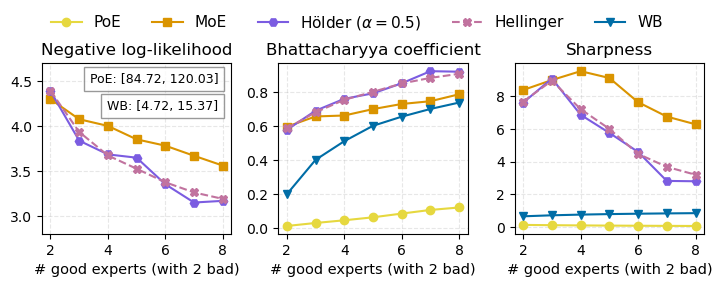

In [6]:
# --- Colors (extended palette) ---
method_colors = {
    "PoE": "#E6D83F",
    "MoE": "#DA9400",   # same color, different linestyle
    r"Hölder ($\alpha=0.5$)": "#7B5CE1",   # same color, different linestyle
    "Hellinger": "#C1739F",
    "WB": "#006DA6",
}

markers = ['o', 's', 'H', 'X', 'v']

# --- Run ---
results = run_metrics_good(max_M=8, n_bad=2, n_samples=250)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(7.33, 2.90))
metrics = ["NLL", "BC", "Sharp"]
names   = ["Negative log-likelihood", "Bhattacharyya coefficient", "Sharpness"]

for ax, metric, name in zip(axes, metrics, names):
    for (method, color), marker in zip(method_colors.items(), markers):
        linestyle = "--" if "Hellinger" in method else "-"
        yvals = results[method][metric]

        if metric == "NLL" and method == "PoE":
            # Show min/max in a text box
            min_val, max_val = min(yvals), max(yvals)
            ax.text(
                5.6, 4.6, f"PoE: [{min_val:.2f}, {max_val:.2f}]",
                fontsize=9, ha="center", va="top",
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
            )
        if metric == "NLL" and method == "WB":
            # Show min/max in a text box
            min_val, max_val = min(yvals), max(yvals)
            ax.text(
                5.9, 4.3, f"WB: [{min_val:.2f}, {max_val:.2f}]",
                fontsize=9, ha="center", va="top",
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
            )
        else:
            ax.plot(range(2, 9), yvals,
                    marker=marker, label=method,
                    color=color, linestyle=linestyle)

    if metric == "NLL":
        ax.set_ylim(2.8, 4.7)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("# good experts (with 2 bad)", fontsize=10.5)
    ax.grid(True, alpha=0.3, linestyle="--")

# Legend
fig.legend(
    handles=[plt.Line2D([0], [0], color=c, marker=marker,
                        label=m, linestyle="--" if "Hellinger" in m else "-")
             for (m, c), marker in zip(method_colors.items(), markers)],
    loc="upper center",
    ncol=5,
    frameon=False,
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()
fig.savefig("plots/good_2bad_experts.pdf", format="pdf", bbox_inches="tight")

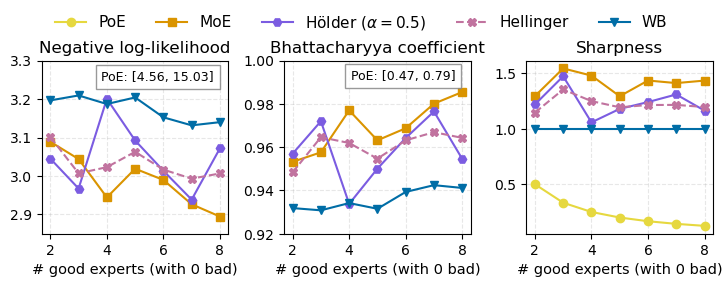

In [7]:
# --- Run ---
results = run_metrics_good(max_M=8, n_bad=0, n_samples=250)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(7.33, 2.90))
metrics = ["NLL", "BC", "Sharp"]
names   = ["Negative log-likelihood", "Bhattacharyya coefficient", "Sharpness"]

for ax, metric, name in zip(axes, metrics, names):
    for (method, color), marker in zip(method_colors.items(), markers):
        linestyle = "--" if "Hellinger" in method else "-"
        yvals = results[method][metric]

        if metric == "NLL" and method == "PoE":
            # Show min/max in a text box
            min_val, max_val = min(yvals), max(yvals)
            ax.text(
                5.8, 3.275, f"PoE: [{min_val:.2f}, {max_val:.2f}]",
                fontsize=9, ha="center", va="top",
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
            )
        if metric == "BC" and method == "PoE":
            # Show min/max in a text box
            min_val, max_val = min(yvals), max(yvals)
            ax.text(
                5.9, 0.996, f"PoE: [{min_val:.2f}, {max_val:.2f}]",
                fontsize=9, ha="center", va="top",
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
            )
        else:
            ax.plot(range(2, 9), yvals,
                    marker=marker, label=method,
                    color=color, linestyle=linestyle)

    if metric == "NLL":
        ax.set_ylim(2.85, 3.3)
    if metric == "BC":
        ax.set_ylim(0.92, 1.0)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("# good experts (with 0 bad)", fontsize=10.5)
    ax.grid(True, alpha=0.3, linestyle="--")

# Legend
fig.legend(
    handles=[plt.Line2D([0], [0], color=c, marker=marker,
                        label=m, linestyle="--" if "Hellinger" in m else "-")
             for (m, c), marker in zip(method_colors.items(), markers)],
    loc="upper center",
    ncol=7,
    frameon=False,
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
fig.savefig("plots/good_0bad_experts.pdf", format="pdf", bbox_inches="tight")